In [1]:
import numpy as np
import torch
from dataclasses import dataclass
from typing import Tuple


@dataclass
class DRLToyConfig:
    state_dim: int = 7      # NOTE: now 7 (x, y, vx, risk, load, ctx, ctx2)
    n_actions: int = 4
    n_objectives: int = 3
    n_samples: int = 20000
    # noise per objective
    noise_std: Tuple[float, float, float] = (0.04, 0.06, 0.05)


def sample_states(cfg: DRLToyConfig, n: int):
    """
    state = [x, y, vx, risk, load, ctx, ctx2]

    - ctx ∈ {0,1,2}: main regime variable (strong signal for MoE)
    - ctx2 ∈ {-1, +1}: secondary context that affects some objectives differently
    """
    x = np.random.uniform(-1.0, 1.0, size=(n, 1))
    y = np.random.uniform(-1.0, 1.0, size=(n, 1))
    vx = np.random.normal(0.0, 0.5, size=(n, 1))
    risk = np.random.uniform(0.0, 1.0, size=(n, 1))
    load = np.random.uniform(0.0, 1.0, size=(n, 1))

    # three regimes
    ctx = np.random.randint(0, 3, size=(n, 1))          # 0, 1, 2
    # secondary binary context: -1 or +1
    ctx2 = np.random.choice([-1.0, 1.0], size=(n, 1))

    state = np.concatenate(
        [x, y, vx, risk, load, ctx.astype(np.float32), ctx2.astype(np.float32)],
        axis=1
    ).astype(np.float32)
    return state


def sample_actions(cfg: DRLToyConfig, n: int):
    """
    Discrete actions {0,1,2,3}, represented as one-hot.
    """
    a_idx = np.random.randint(0, cfg.n_actions, size=(n,))
    a_onehot = np.eye(cfg.n_actions, dtype=np.float32)[a_idx]  # (n, n_actions)
    return a_idx, a_onehot


def compute_q_values(states: np.ndarray, a_idx: np.ndarray, cfg: DRLToyConfig):
    """
    Ground-truth multi-objective Q(s,a) with 3 clearly different regimes.

    states: (n, 7) = [x, y, vx, risk, load, ctx, ctx2]
    a_idx:  (n,)
    """
    x = states[:, 0]
    y = states[:, 1]
    vx = states[:, 2]
    risk = states[:, 3]
    load = states[:, 4]
    ctx = states[:, 5]   # 0,1,2 (float)
    ctx2 = states[:, 6]  # -1 or +1

    # choose a goal based on ctx (different per regime)
    goal_x = np.where(ctx < 0.5, 0.7, np.where(ctx < 1.5, -0.7, 0.0))
    goal_y = np.where(ctx < 1.5, 0.7, -0.2)

    dx = x - goal_x
    dy = y - goal_y
    d = np.sqrt(dx**2 + dy**2 + 1e-8)

    # action encoding helpers
    a_left = (a_idx == 0).astype(np.float32)
    a_right = (a_idx == 1).astype(np.float32)
    a_up = (a_idx == 2).astype(np.float32)
    a_down = (a_idx == 3).astype(np.float32)

    energy = np.array([1.0, 1.2, 1.1, 1.3], dtype=np.float32)
    action_energy = energy[a_idx]

    # --- masks for regimes ---
    m0 = (ctx < 0.5).astype(np.float32)             # regime 0
    m1 = ((ctx >= 0.5) & (ctx < 1.5)).astype(np.float32)  # regime 1
    m2 = (ctx >= 1.5).astype(np.float32)            # regime 2

    # =========================================================
    # Objective 1: "Performance"  Q1
    # =========================================================
    # Regime 0: almost linear / smooth, mild interactions
    q1_reg0 = -d + 0.4 * vx - 0.2 * a_left + 0.1 * a_up

    # Regime 1: highly nonlinear, oscillatory and cross-terms
    q1_reg1 = (
        0.8 * np.sin(3.0 * d + 0.5 * x)
        + 0.4 * np.cos(2.0 * x - y)
        + 0.3 * np.tanh(2.0 * vx + 0.5 * ctx2)
    )

    # Regime 2: piecewise with sharp kinks around d ~ 0.4 and x ~ 0
    q1_reg2 = np.where(
        d < 0.4,
        1.0 - 2.0 * d + 0.2 * vx,
        -0.5 * d + 0.3 * np.sign(x) * ctx2
    )
    # sharp extra kink in a narrow band
    q1_reg2 += 0.7 * ((np.abs(x) < 0.2) & (d > 0.6)).astype(np.float32)

    Q1 = m0 * q1_reg0 + m1 * q1_reg1 + m2 * q1_reg2

    # =========================================================
    # Objective 2: "Safety"  Q2
    # =========================================================
    risky_action = a_right

    # Regime 0: smooth quadratic in risk + distance
    q2_reg0 = -(risk + 0.4 * risky_action) ** 2 - 0.1 * d + 0.05 * (1.0 - load)

    # Regime 1: non-monotone in risk, interacts with ctx2 and x
    q2_reg1 = (
        -0.8 * np.cos(2.5 * risk * np.pi)  # oscillatory in risk
        + 0.2 * np.sin(3.0 * x)
        - 0.15 * d
        + 0.3 * ctx2 * (a_down - a_up)
    )

    # Regime 2: strongly piecewise, large penalties near certain "danger strips"
    danger_strip = ((x > -0.2) & (x < 0.2) & (y < 0.0)).astype(np.float32)
    q2_reg2 = (
        -1.5 * danger_strip
        - 0.3 * (risk + 0.1 * a_right)
        + 0.25 * (1.0 - d)
    )
    # extra penalty if high risk and high load with action "right"
    q2_reg2 += -0.8 * ((risk > 0.7) & (load > 0.6) & (a_right > 0)).astype(np.float32)

    Q2 = m0 * q2_reg0 + m1 * q2_reg1 + m2 * q2_reg2

    # =========================================================
    # Objective 3: "Efficiency / Cost"  Q3
    # =========================================================
    # Regime 0: mostly linear in energy + |vx|, mild rewards near goal
    q3_reg0 = (
        -0.6 * action_energy - 0.4 * np.abs(vx)
        + 0.3 * (1.0 - d)
        - 0.1 * load
    )

    # Regime 1: strongly nonlinear in (load, risk), with ctx2 flipping pattern
    q3_reg1 = (
        -0.7 * np.exp(0.7 * load)
        + 0.4 * (1.0 - risk) * ctx2
        + 0.2 * np.sin(4.0 * d)
        - 0.1 * action_energy
    )

    # Regime 2: discontinuous efficiency with big jumps in certain bands
    close = (d < 0.3).astype(np.float32)
    middle = ((d >= 0.3) & (d <= 0.7)).astype(np.float32)
    far = (d > 0.7).astype(np.float32)

    q3_reg2 = (
        0.8 * close
        - 0.2 * middle
        - 0.5 * far
        - 0.3 * np.abs(vx)
        - 0.2 * action_energy
        + 0.15 * (1.0 - load) * ctx2
    )
    # jump around boundary x ~ 0.5 when action is "up"
    q3_reg2 += 0.6 * ((x > 0.4) & (x < 0.6) & (a_up > 0)).astype(np.float32)

    Q3 = m0 * q3_reg0 + m1 * q3_reg1 + m2 * q3_reg2

    # Stack all objectives
    Q = np.stack([Q1, Q2, Q3], axis=1).astype(np.float32)

    # Add Gaussian noise per objective
    noise = np.stack(
        [
            np.random.normal(0.0, cfg.noise_std[0], size=Q.shape[0]),
            np.random.normal(0.0, cfg.noise_std[1], size=Q.shape[0]),
            np.random.normal(0.0, cfg.noise_std[2], size=Q.shape[0]),
        ],
        axis=1,
    ).astype(np.float32)

    Q_noisy = Q + noise
    return Q_noisy


def generate_drl_toy_dataset(cfg: DRLToyConfig):
    """
    Returns:
      X: critic input = concat[state, onehot(action)]  shape (N, state_dim + n_actions)
      Q: target multi-objective value vector            shape (N, n_objectives)
      states: raw state (without one-hot)
      actions: integer action indices
    """
    states = sample_states(cfg, cfg.n_samples)
    a_idx, a_onehot = sample_actions(cfg, cfg.n_samples)
    Q = compute_q_values(states, a_idx, cfg)

    X = np.concatenate([states, a_onehot], axis=1).astype(np.float32)

    X_torch = torch.from_numpy(X)
    Q_torch = torch.from_numpy(Q)

    return X_torch, Q_torch, states, a_idx


In [2]:
cfg = DRLToyConfig(n_samples=20000)
X, Q, states, actions = generate_drl_toy_dataset(cfg)

input_dim = X.shape[1]           # should now be state_dim (7) + 4 = 11
num_objectives = Q.shape[1]      # 3

N = X.shape[0]



================= Replication 1/10 =================
--- Training FC (rep 1) ---
FC - Final Val MSE: 2.7931
FC - Test MSE (total): 2.6405
FC - Test MSE (per objective): [2.657232  2.4930253 2.7713487]
--- Training MH (rep 1) ---
MH - Final Val MSE: 2.5496
MH - Test MSE (total): 2.6252
MH - Test MSE (per objective): [2.740531  2.5689046 2.5661738]
--- Training MoE (rep 1) ---
MoE - Final Val MSE: 2.2198
MoE - Test MSE (total): 2.0949
MoE - Test MSE (per objective): [1.8842975 2.192743  2.2077067]
--- Training MH+MoE (rep 1) ---
MH+MoE - Final Val MSE: 1.8780
MH+MoE - Test MSE (total): 1.8104
MH+MoE - Test MSE (per objective): [1.7923434 1.7705687 1.8682839]

================= Replication 2/10 =================
--- Training FC (rep 2) ---
FC - Final Val MSE: 2.5075
FC - Test MSE (total): 2.5633
FC - Test MSE (per objective): [2.6019616 2.6538548 2.4340527]
--- Training MH (rep 2) ---
MH - Final Val MSE: 2.4317
MH - Test MSE (total): 2.5038
MH - Test MSE (per objective): [2.442265  2.604

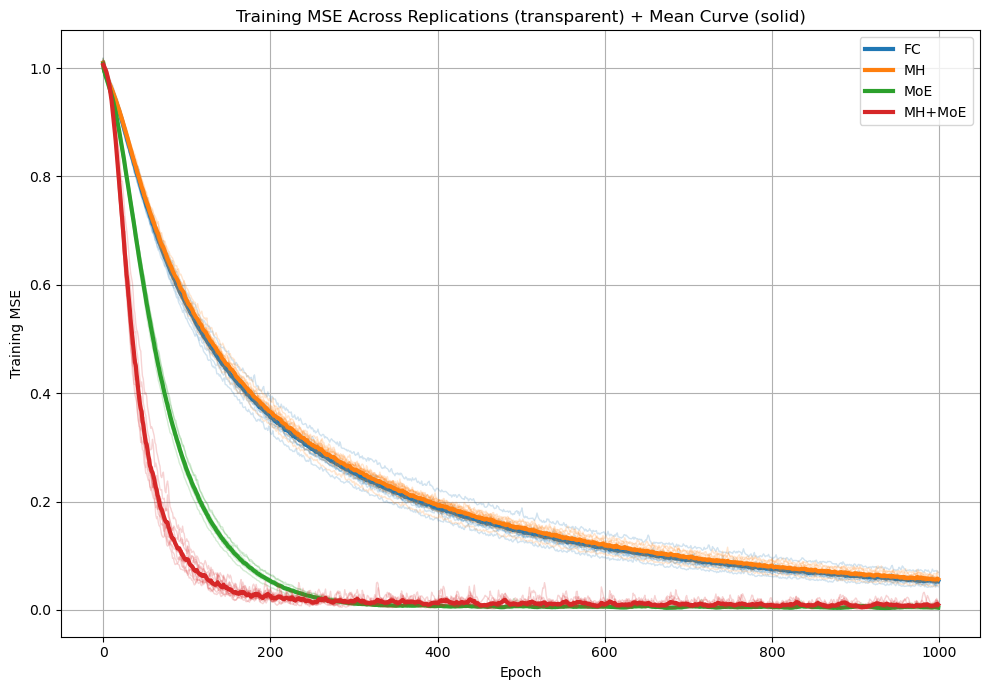

C:\Users\kyudongk\AppData\Local\Temp\ipykernel_29484\2026619195.py:544: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


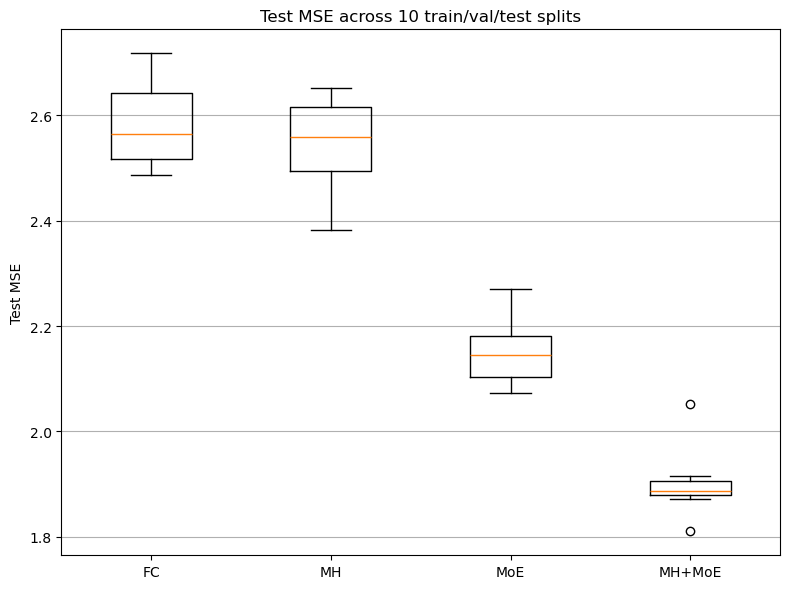


=== Test MSE Summary (across replications) ===
FC         | mean=2.5843 | std=0.0757 | min=2.4865 | max=2.7177
MH         | mean=2.5431 | std=0.0850 | min=2.3821 | max=2.6525
MoE        | mean=2.1505 | std=0.0581 | min=2.0721 | max=2.2697
MH+MoE     | mean=1.8983 | std=0.0579 | min=1.8104 | max=2.0519


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pandas as pd  # NEW: for CSV logging

# ============================================================
#  Device & seed
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

# ============================================================
#  1. Four critic architectures
#  (UNCHANGED: your CriticFC, CriticMultiHead, CriticMoE, CriticMHMoE,
#   CriticFeatureMHMoE definitions go here)
# ============================================================

class CriticFC(nn.Module):
    """
    Simple fully-connected critic:
    x -> shared MLP -> R^{num_objectives}
    """
    def __init__(self, input_dim, num_objectives, h1=128, h2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, num_objectives)
        )

    def forward(self, x):
        return self.net(x)

class CriticMultiHead(nn.Module):
    """
    Shared-bottom multi-head critic:
    x -> trunk(z) -> heads_i(z), i=1..m, each scalar -> concat -> R^m
    """
    def __init__(self, input_dim, num_objectives, h1=128, h2=128):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU()
        )
        self.heads = nn.ModuleList([
            nn.Linear(h2, 1) for _ in range(num_objectives)
        ])

    def forward(self, x):
        z = self.trunk(x)  # [B, h2]
        outs = [head(z) for head in self.heads]  # list of [B,1]
        return torch.cat(outs, dim=-1)  # [B, m]

class CriticMoE(nn.Module):
    """
    Vector-valued MoE critic:
    - K experts; each maps x -> R^m
    - Gate depends only on x
    - Includes load-balance regularization and gate entropy regularization.
    """
    def __init__(
        self,
        input_dim,
        num_objectives,
        num_experts=4,
        h1=128,
        h2=128,
        gate_temp=1.0,
        lb_coef=1e-3,
        ent_coef=1e-3,
    ):
        super().__init__()
        self.num_objectives = num_objectives
        self.num_experts = num_experts
        self.gate_temp = gate_temp
        self.lb_coef = lb_coef
        self.ent_coef = ent_coef

        # Experts: x -> R^m
        def make_expert():
            return nn.Sequential(
                nn.Linear(input_dim, h1), nn.ReLU(),
                nn.Linear(h1, h2), nn.ReLU(),
                nn.Linear(h2, num_objectives)
            )
        self.experts = nn.ModuleList([make_expert() for _ in range(num_experts)])

        # Gate: x -> logits over experts
        self.gate = nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(),
            nn.Linear(h1, num_experts)
        )

    def forward_with_gates(self, x):
        """
        Returns:
          v_mix: [B,m]  mixture value
          probs: [B,K]  gate probabilities
        """
        expert_vals = torch.stack([E(x) for E in self.experts], dim=1)  # [B,K,m]
        logits = self.gate(x) / self.gate_temp     # [B,K]
        probs = F.softmax(logits, dim=-1)          # [B,K]
        v_mix = (expert_vals * probs.unsqueeze(-1)).sum(dim=1)  # [B,m]
        return v_mix, probs

    def forward(self, x):
        v_mix, _ = self.forward_with_gates(x)
        return v_mix

class CriticMHMoE(nn.Module):
    """
    Heads-then-MoE critic:
    x -> trunk z
      -> base multi-head h(s) in R^m
      -> K experts in objective space: h -> R^m
      -> gate(z) over K experts
      -> mixture -> Q(s) in R^m
    """
    def __init__(
        self,
        input_dim,
        num_objectives,
        num_experts=4,
        trunk_h1=224,
        trunk_h2=224,
        couple_type="affine",
        expert_hidden=256,
        gate_temp=1.0,
        lb_coef=1e-3,
        ent_coef=1e-3,
    ):
        super().__init__()
        self.m = num_objectives
        self.K = num_experts
        self.couple_type = couple_type
        self.gate_temp = gate_temp
        self.lb_coef = lb_coef
        self.ent_coef = ent_coef

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, trunk_h1), nn.ReLU(),
            nn.Linear(trunk_h1, trunk_h2), nn.ReLU()
        )

        self.base_heads = nn.ModuleList([
            nn.Linear(trunk_h2, 1) for _ in range(num_objectives)
        ])

        if couple_type == "affine":
            self.A = nn.Parameter(
                torch.stack([torch.eye(self.m) for _ in range(num_experts)], dim=0)
            )
            self.b = nn.Parameter(torch.zeros(num_experts, self.m))
            self.experts = None
            with torch.no_grad():
                for k in range(num_experts):
                    self.A[k].copy_(torch.eye(self.m))
                    self.b[k].zero_()
        else:
            self.experts = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(self.m, expert_hidden), nn.ReLU(),
                    nn.Linear(expert_hidden, self.m)
                ) for _ in range(num_experts)
            ])
            self.A = None
            self.b = None

        self.gate = nn.Sequential(
            nn.Linear(trunk_h2, 64), nn.ReLU(),
            nn.Linear(64, num_experts)
        )

    def _base_h(self, z):
        return torch.cat([head(z) for head in self.base_heads], dim=-1)

    def _experts_apply(self, h):
        if self.experts is not None:
            return torch.stack([E(h) for E in self.experts], dim=1)
        return torch.einsum("kmn,bn->bkm", self.A, h) + self.b.unsqueeze(0)

    def _gate_probs(self, z):
        logits = self.gate(z) / self.gate_temp   # [B, K]
        return F.softmax(logits, dim=-1)

    def forward_with_gates(self, x):
        z = self.trunk(x)                 # [B, trunk_h2]
        h = self._base_h(z)               # [B, m]
        E = self._experts_apply(h)        # [B, K, m]
        gate_p = self._gate_probs(z)      # [B, K]
        v_mix = (E * gate_p.unsqueeze(-1)).sum(dim=1)  # [B, m]
        return v_mix, gate_p

    def forward(self, x):
        v_mix, _ = self.forward_with_gates(x)
        return v_mix

class CriticFeatureMHMoE(nn.Module):
    """
    Feature-level Multi-head + MoE critic:
    x -> trunk z
       -> K feature experts E_k(z)
       -> gate(z)
       -> z_moe = sum_k p_k * z_k
       -> multi-head on z_moe -> Q(s)
    """
    def __init__(
        self,
        input_dim,
        num_objectives,
        num_experts=4,
        trunk_h1=128,
        trunk_h2=128,
        expert_hidden=128,
        gate_temp=1.0,
        lb_coef=1e-3,
        ent_coef=1e-3,
        use_residual=True,
    ):
        super().__init__()
        self.m = num_objectives
        self.K = num_experts
        self.gate_temp = gate_temp
        self.lb_coef = lb_coef
        self.ent_coef = ent_coef
        self.use_residual = use_residual
        self.feature_dim = trunk_h2

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, trunk_h1), nn.ReLU(),
            nn.Linear(trunk_h1, trunk_h2), nn.ReLU()
        )

        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(trunk_h2, expert_hidden), nn.ReLU(),
                nn.Linear(expert_hidden, trunk_h2)
            ) for _ in range(num_experts)
        ])

        self.gate = nn.Sequential(
            nn.Linear(trunk_h2, 64), nn.ReLU(),
            nn.Linear(64, num_experts)
        )

        self.heads = nn.ModuleList([
            nn.Linear(trunk_h2, 1) for _ in range(num_objectives)
        ])

    def _apply_experts(self, z):
        expert_feats = torch.stack([E(z) for E in self.experts], dim=1)
        if self.use_residual:
            z_expanded = z.unsqueeze(1)
            expert_feats = z_expanded + expert_feats
        return expert_feats

    def _gate_probs(self, z):
        logits = self.gate(z) / self.gate_temp
        return F.softmax(logits, dim=-1)

    def forward_with_gates(self, x):
        z = self.trunk(x)                       # [B, D]
        expert_feats = self._apply_experts(z)   # [B, K, D]
        gate_p = self._gate_probs(z)            # [B, K]
        z_moe = (expert_feats * gate_p.unsqueeze(-1)).sum(dim=1)  # [B, D]
        q_list = [head(z_moe) for head in self.heads]
        q_mix = torch.cat(q_list, dim=-1)       # [B, m]
        return q_mix, gate_p

    def forward(self, x):
        q_mix, _ = self.forward_with_gates(x)
        return q_mix

# ============================================================
#  2. Training / evaluation utilities (UNCHANGED)
# ============================================================

def train_critic(model, X_train, Y_train, X_val, Y_val,
                 n_epochs=100, batch_size=256, lr=1e-3):
    model.to(device)
    model.train()

    train_ds = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_mse_history = []
    val_mse_history = []

    for epoch in range(n_epochs):
        epoch_mse_sum = 0.0
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            if not hasattr(model, "forward_with_gates"):
                pred = model(xb)
                mse_loss = criterion(pred, yb)
                total_loss = mse_loss
            else:
                pred, gate_probs = model.forward_with_gates(xb)
                mse_loss = criterion(pred, yb)

                p_mean = gate_probs.mean(dim=0)
                K = p_mean.size(0)
                uniform = torch.full_like(p_mean, 1.0 / K)
                lb_loss = F.kl_div((p_mean + 1e-8).log(), uniform, reduction="batchmean")

                gate_probs_clamped = gate_probs.clamp_min(1e-8)
                gate_entropy = -(gate_probs_clamped * gate_probs_clamped.log()).sum(dim=1).mean()

                lb_coef  = getattr(model, "lb_coef", 0.0)
                ent_coef = getattr(model, "ent_coef", 0.0)

                total_loss = mse_loss + lb_coef * lb_loss - ent_coef * gate_entropy

            optim.zero_grad()
            total_loss.backward()
            optim.step()

            epoch_mse_sum += mse_loss.item() * xb.size(0)

        train_mse = epoch_mse_sum / len(train_ds)
        train_mse_history.append(train_mse)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val.to(device))
            val_mse = criterion(val_pred, Y_val.to(device)).item()
        val_mse_history.append(val_mse)

    return train_mse_history, val_mse_history

def mse_per_objective(model, X, Y):
    model.eval()
    with torch.no_grad():
        pred = model(X.to(device)).cpu()
    mse_all = ((pred - Y) ** 2).mean(dim=0)
    mse_total = ((pred - Y) ** 2).mean().item()
    return mse_total, mse_all.numpy()

# ============================================================
#  3. Main experiment + CSV logging
# ============================================================

if __name__ == "__main__":
    N, input_dim, num_objectives = 5000, 10, 3
    X = torch.randn(N, input_dim)
    Q = torch.randn(N, num_objectives)

    X = X.to(device)
    Q = Q.to(device)

    n_train = int(0.7 * N)
    n_val   = int(0.15 * N)
    n_test  = N - n_train - n_val

    n_reps = 10
    n_epochs = 1000

    test_mse_across_reps = {
        "FC": [],
        "MH": [],
        "MoE": [],
        "MH+MoE": [],
    }

    train_curves_all = {
        "FC": [],
        "MH": [],
        "MoE": [],
        "MH+MoE": [],
    }

    # NEW: storage for CSVs
    summary_rows = []   # per model/rep summary
    pred_rows = []      # per test sample: true vs pred Q
    gate_rows = []      # per test sample: expert gate probs for MoE-type models

    for rep in range(n_reps):
        print(f"\n================= Replication {rep+1}/{n_reps} =================")

        torch.manual_seed(42 + rep)
        np.random.seed(42 + rep)

        idx = np.arange(N)
        np.random.shuffle(idx)

        idx_train = idx[:n_train]
        idx_val   = idx[n_train:n_train + n_val]
        idx_test  = idx[n_train + n_val:]

        X_train, Y_train = X[idx_train], Q[idx_train]
        X_val,   Y_val   = X[idx_val],   Q[idx_val]
        X_test,  Y_test  = X[idx_test],  Q[idx_test]

        models = {
            "FC": CriticFC(input_dim, num_objectives),
            "MH": CriticMultiHead(input_dim, num_objectives),
            "MoE": CriticMoE(
                input_dim, num_objectives, num_experts=4,
                lb_coef=1e-2, ent_coef=1e-2
            ),
            "MH+MoE": CriticMHMoE(
                input_dim, num_objectives, num_experts=4,
                couple_type="mlp",
                lb_coef=1e-2, ent_coef=1e-2
            ),
        }

        for name, model in models.items():
            print(f"--- Training {name} (rep {rep+1}) ---")
            train_curve, val_curve = train_critic(
                model,
                X_train, Y_train,
                X_val, Y_val,
                n_epochs=n_epochs,
                batch_size=256,
                lr=1e-3,
            )

            train_curves_all[name].append(train_curve)
            val_mse = val_curve[-1]

            test_total_mse, test_mse_vec = mse_per_objective(
                model, X_test, Y_test
            )
            test_mse_across_reps[name].append(test_total_mse)

            print(f"{name} - Final Val MSE: {val_mse:.4f}")
            print(f"{name} - Test MSE (total): {test_total_mse:.4f}")
            print(f"{name} - Test MSE (per objective): {test_mse_vec}")

            # ---------- NEW: record summary row ----------
            summary_rows.append({
                "rep": rep + 1,
                "model": name,
                "final_val_mse": float(val_mse),
                "test_mse_total": float(test_total_mse),
                "test_mse_q1": float(test_mse_vec[0]),
                "test_mse_q2": float(test_mse_vec[1]),
                "test_mse_q3": float(test_mse_vec[2]),
            })

            # ---------- NEW: record per-sample predictions and gate weights ----------
            model.eval()
            with torch.no_grad():
                if hasattr(model, "forward_with_gates"):
                    pred, gate_probs = model.forward_with_gates(X_test.to(device))
                    gate_np = gate_probs.cpu().numpy()   # [n_test, K]
                else:
                    pred = model(X_test.to(device))
                    gate_np = None

                pred_np = pred.cpu().numpy()            # [n_test, 3]
                true_np = Y_test.cpu().numpy()          # [n_test, 3]

            # per-sample Q true vs pred
            for i in range(n_test):
                sample_id = int(idx_test[i])
                pred_rows.append({
                    "rep": rep + 1,
                    "model": name,
                    "sample_id": sample_id,
                    "Q1_true": float(true_np[i, 0]),
                    "Q2_true": float(true_np[i, 1]),
                    "Q3_true": float(true_np[i, 2]),
                    "Q1_pred": float(pred_np[i, 0]),
                    "Q2_pred": float(pred_np[i, 1]),
                    "Q3_pred": float(pred_np[i, 2]),
                })

            # per-sample gate weights (only for MoE-type)
            if gate_np is not None:
                K = gate_np.shape[1]
                for i in range(n_test):
                    sample_id = int(idx_test[i])
                    row = {
                        "rep": rep + 1,
                        "model": name,
                        "sample_id": sample_id,
                    }
                    for k in range(K):
                        row[f"g_{k}"] = float(gate_np[i, k])
                    gate_rows.append(row)

    # ============================================================
    #  Save CSVs
    # ============================================================
    summary_df = pd.DataFrame(summary_rows)
    pred_df    = pd.DataFrame(pred_rows)
    gate_df    = pd.DataFrame(gate_rows)

    summary_df.to_csv("critic_results_summary.csv", index=False)
    pred_df.to_csv("critic_test_predictions.csv", index=False)
    gate_df.to_csv("critic_gate_weights.csv", index=False)

    # ============================================================
    #  Plot training MSE curves (same as before)
    # ============================================================
    color_map = {
        "FC": "tab:blue",
        "MH": "tab:orange",
        "MoE": "tab:green",
        "MH+MoE": "tab:red",
    }

    plt.figure(figsize=(10, 7))

    for name in train_curves_all.keys():
        curves = train_curves_all[name]
        color = color_map[name]

        for c in curves:
            plt.plot(c, color=color, alpha=0.20, linewidth=1)

        mean_curve = np.mean(np.vstack(curves), axis=0)
        plt.plot(mean_curve, color=color, linewidth=3, label=name)

    plt.xlabel("Epoch")
    plt.ylabel("Training MSE")
    plt.title("Training MSE Across Replications (transparent) + Mean Curve (solid)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ============================================================
    #  Boxplot of test MSE across replications (same as before)
    # ============================================================
    labels = list(test_mse_across_reps.keys())
    data = [test_mse_across_reps[name] for name in labels]

    plt.figure(figsize=(8, 6))
    plt.boxplot(data, labels=labels)
    plt.ylabel("Test MSE")
    plt.title(f"Test MSE across {n_reps} train/val/test splits")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

    # ============================================================
    #  Numerical summary (same as before)
    # ============================================================
    print("\n=== Test MSE Summary (across replications) ===")
    for name in labels:
        arr = np.array(test_mse_across_reps[name])
        print(f"{name:10s} | mean={arr.mean():.4f} | std={arr.std():.4f} | "
              f"min={arr.min():.4f} | max={arr.max():.4f}")


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Adjust paths if needed
pred_df  = pd.read_csv("critic_test_predictions.csv")
gate_df  = pd.read_csv("critic_gate_weights.csv")
summary_df = pd.read_csv("critic_results_summary.csv")

# If you only want four models:
models_to_plot = ["FC", "MH", "MoE", "MH+MoE"]
pred_df = pred_df[pred_df["model"].isin(models_to_plot)].copy()
gate_df = gate_df[gate_df["model"].isin(models_to_plot)].copy()


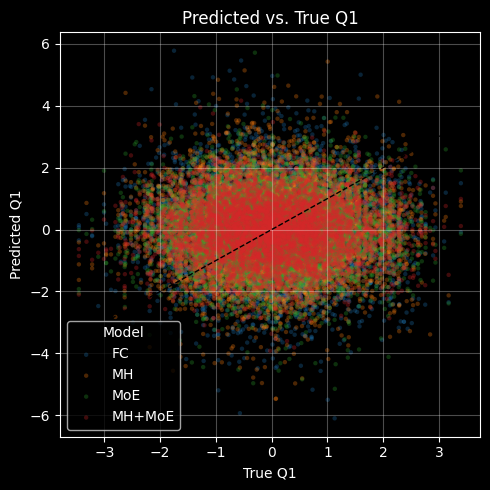

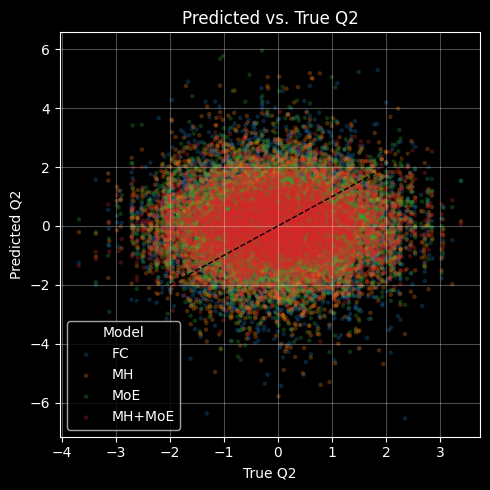

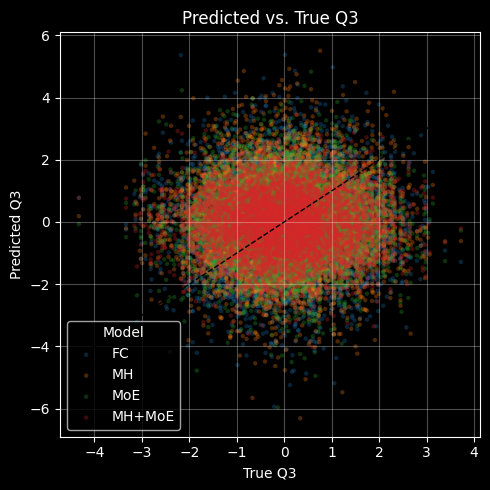

In [5]:
objectives = ["Q1", "Q2", "Q3"]
colors = {
    "FC": "tab:blue",
    "MH": "tab:orange",
    "MoE": "tab:green",
    "MH+MoE": "tab:red",
}

for obj in objectives:
    true_col = f"{obj}_true"
    pred_col = f"{obj}_pred"

    plt.figure(figsize=(5, 5))
    for model in models_to_plot:
        df_m = pred_df[pred_df["model"] == model]
        plt.scatter(
            df_m[true_col],
            df_m[pred_col],
            alpha=0.3,
            s=10,
            label=model,
            color=colors.get(model, None),
            edgecolors="none",
        )

    # y = x reference line
    all_true = pred_df[true_col].values
    _min = np.min(all_true)
    _max = np.max(all_true)
    plt.plot([_min, _max], [_min, _max], "k--", linewidth=1)

    plt.xlabel(f"True {obj}")
    plt.ylabel(f"Predicted {obj}")
    plt.title(f"Predicted vs. True {obj}")
    plt.legend(title="Model")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


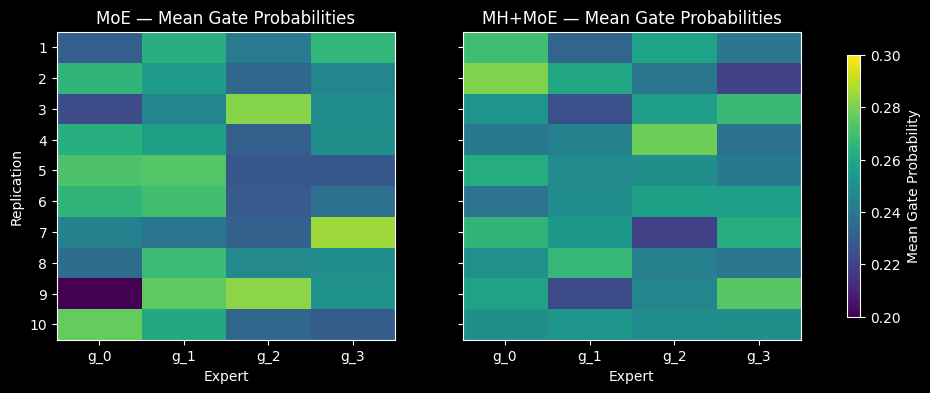

In [6]:
import matplotlib.pyplot as plt
import numpy as np

models_to_plot = ["MoE", "MH+MoE"]   # two subplots

# Define enhanced color range to highlight differences
vmin, vmax = 0.20, 0.30   # adjust if needed

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, model in zip(axes, models_to_plot):

    df_m = gate_df[gate_df["model"] == model].copy()
    gate_cols = [c for c in df_m.columns if c.startswith("g_")]
    K = len(gate_cols)

    # mean gate per replication
    pivot = df_m.groupby("rep")[gate_cols].mean()

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{model} — Mean Gate Probabilities")
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(gate_cols)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Expert")

axes[0].set_ylabel("Replication")

# One shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Mean Gate Probability")

plt.show()


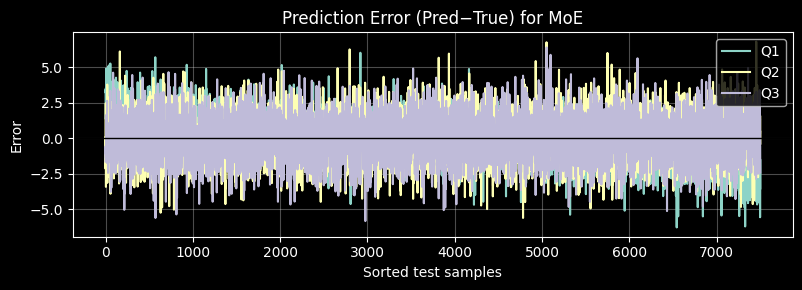

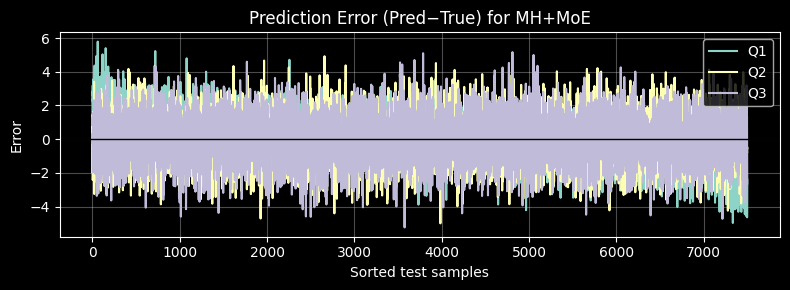

In [7]:
for model in models_to_plot:
    df_m = pred_df[pred_df["model"] == model].copy()
    df_m = df_m.sort_values("Q1_true")

    plt.figure(figsize=(8, 3))
    for obj in objectives:
        diff = df_m[f"{obj}_pred"].values - df_m[f"{obj}_true"].values
        plt.plot(diff, label=obj, linewidth=1.5)

    plt.title(f"Prediction Error (Pred−True) for {model}")
    plt.xlabel("Sorted test samples")
    plt.ylabel("Error")
    plt.axhline(0, color="black", linewidth=1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [12]:
pred_df

,rep,model,sample_id,Q1_true,Q2_true,Q3_true,Q1_pred,Q2_pred,Q3_pred
0,1,FC,4170,0.252705,-0.768535,1.134996,1.326784,-0.807561,0.970849
1,1,FC,467,-0.647360,0.514342,-0.593834,1.483587,-2.524910,1.113882
2,1,FC,5,-2.109320,0.060484,2.026151,0.326901,-0.089832,1.920170
3,1,FC,919,0.495358,1.788932,0.642687,-0.415380,0.513043,4.256876
4,1,FC,2595,1.854960,0.157651,2.980479,-0.128233,1.557630,-0.215829
...,...,...,...,...,...,...,...,...,...
37495,10,MH+MoEforfeature,3989,-0.819889,0.900700,0.633025,-0.365398,0.963305,-0.806994
37496,10,MH+MoEforfeature,1733,-1.543732,-0.849237,-0.257644,-0.866319,-2.103324,0.719983
37497,10,MH+MoEforfeature,1760,1.123147,-0.750343,2.332218,0.857329,0.320426,0.489693
37498,10,MH+MoEforfeature,485,0.909706,0.665441,-0.257622,-0.089748,0.024419,-0.140925


C:\Users\yujin\AppData\Local\Temp\ipykernel_29992\835007004.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\yujin\AppData\Local\Temp\ipykernel_29992\835007004.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\yujin\AppData\Local\Temp\ipykernel_29992\835007004.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


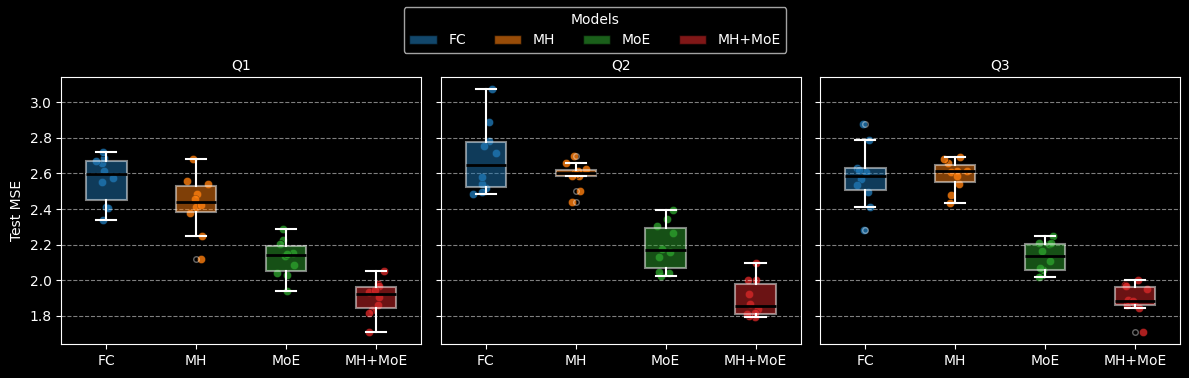

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# =====================================================
# Load your CSV
# =====================================================
df = pd.read_csv("critic_results_summary.csv")

models_to_plot = ["FC", "MH", "MoE", "MH+MoE"]
labels = ["FC", "MH", "MoE", "MH+MoE"]
objectives = ["test_mse_q1", "test_mse_q2", "test_mse_q3"]
objective_labels = ["Q1", "Q2", "Q3"]

# Color map matching your training-curve & test-MSE boxplot
color_map = {
    "FC": "tab:blue",
    "MH": "tab:orange",
    "MoE": "tab:green",
    "MH+MoE": "tab:red",
}

colors = [color_map[m] for m in models_to_plot]

# =====================================================
# Prepare data
# =====================================================
data_per_obj = {}
for obj in objectives:
    data_per_obj[obj] = [
        df[df["model"] == m][obj].values
        for m in models_to_plot
    ]

# =====================================================
# Plot: 3 subplots, same style as your Test MSE boxplot
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for idx, obj in enumerate(objectives):
    ax = axes[idx]

    # Create the boxplot
    bp = ax.boxplot(
        data_per_obj[obj],
        labels=labels,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color="black", linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=4, alpha=0.4),
    )

    # Color the boxes
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    # Overlay jittered scatter points
    for i, (model, color) in enumerate(zip(models_to_plot, colors)):
        y = df[df["model"] == model][obj].values
        x = np.random.normal(i + 1, 0.06, size=len(y))
        ax.scatter(
            x, y, alpha=0.8, s=35,
            color=color, edgecolor="black", linewidth=0.4
        )

    ax.set_title(f"{objective_labels[idx]}", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    if idx == 0:
        ax.set_ylabel("Test MSE")

# Legend consistent with your style
legend_handles = [
    Patch(facecolor=colors[i], edgecolor="black", alpha=0.6, label=labels[i])
    for i in range(len(models_to_plot))
]

fig.legend(
    handles=legend_handles,
    title="Models",
    loc="upper center",
    ncol=4,
    frameon=True,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()


C:\Users\yujin\AppData\Local\Temp\ipykernel_29992\1579826195.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


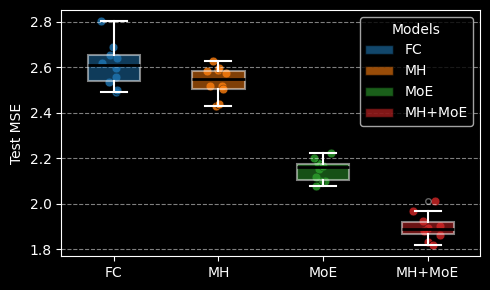

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models_to_plot = ["FC", "MH", "MoE", "MH+MoE"]

# Extract data
labels = ["FC", "MH", "MoE", "MH+MoE"]
data = [test_mse_across_reps[name] for name in models_to_plot]

# Colors from your line plot
colors = [color_map[name] for name in models_to_plot]

plt.figure(figsize=(5, 3))

# --- Create the boxplot first ---
box = plt.boxplot(
    data,
    labels=labels,
    patch_artist=True,     # allow color fill
    widths=0.5,
    medianprops=dict(color="black", linewidth=2),
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=4, alpha=0.4)
)

# --- Color each box according to model color ---
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

# --- Add jittered scatter points on top of each box ---
for i, (name, color) in enumerate(zip(models_to_plot, colors)):
    y = np.array(test_mse_across_reps[name])
    x = np.random.normal(i + 1, 0.06, size=len(y))   # jitter around box position
    plt.scatter(x, y, alpha=0.8, s=40, color=color, edgecolor="black", linewidth=0.5)

# === ADD LEGEND HERE ===
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=colors[i], edgecolor="black", 
          alpha=0.6, label=labels[i])
    for i in range(len(labels))
]

plt.legend(handles=legend_handles, title="Models",
           loc="upper right", frameon=True)
   
plt.ylabel("Test MSE")
#plt.title(f"Test MSE Across {n_reps} Splits (Boxplot + Scatter)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



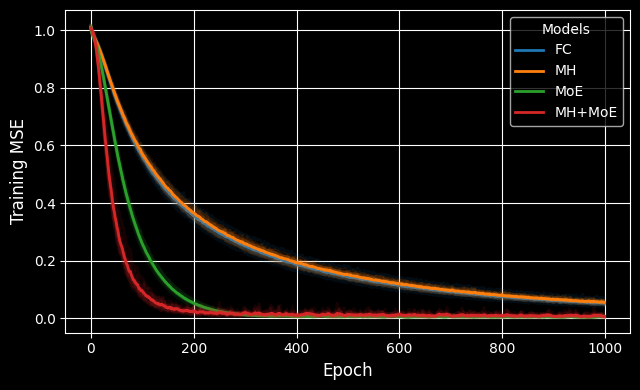

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models_to_plot = ["FC", "MH", "MoE", "MH+MoE"]

plt.figure(figsize=(6.5, 4))

# Store legend handles manually
legend_handles = []

for name in models_to_plot:
    curves = train_curves_all[name]
    color = color_map[name]

    # plot each replication as transparent line
    for c in curves:
        plt.plot(c, color=color, alpha=0.10, linewidth=2)

    # compute mean curve
    mean_curve = np.mean(np.vstack(curves), axis=0)
    plt.plot(mean_curve, color=color, linewidth=2)
    label_name=name

    # add proxy handle for legend
    legend_handles.append(
        Line2D([0], [0], color=color, linewidth=2, label=name)
    )

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Training MSE",fontsize=12)
plt.grid(True)

# Use the custom handles for legend
plt.legend(handles=legend_handles, title="Models", frameon=True)

plt.tight_layout()
plt.show()
